# 37 — Calibration & Anchor Justification

**Companion to [NB 36 (Tier P)](36_tierP_persona_null.ipynb).** Tier P proved the model
*ranks* agents correctly (Spearman ρ ≈ 0.62). It deliberately left the **level** question open.
This notebook answers it and turns the answer into the formal justification for anchoring Day 0
to ground truth.

## The argument in three beats

1. **The raw model is inflated.** The Tier-P `real` arm *is* the no-anchor world
   (`day0_anchor="llm_survey"` → the LLM derives its own opinion). We measure the inflation
   precisely with standard calibration metrics.
2. **It is a *level* problem, not a *rank* problem.** Rank fidelity is already ρ ≈ 0.62 (Tier P);
   here we show the error is (approximately) a common additive offset with preserved ordering —
   not a scrambling of who believes what.
3. **Anchoring removes exactly this error, by construction.** In `src/cag/abm/sim.py::_run_day0`:
   `llm_survey` lets the LLM pick the number (biased); `ground_truth` seeds Day-0 = real YouGov
   (no LLM call); **`ground_truth_with_rationale`** (the production default) seeds the *number*
   from ground truth and lets the LLM write only the *rationale*. So the anchored world has
   Day-0 MBE = 0 and ρ = 1.0 **by construction**, while keeping a coherent reasoning chain for the
   dynamics. The inflation we measure here is precisely what that anchor zeroes out.

## What we compute (standard metrics only)

* **MBE** — mean bias error, signed `mean(LLM − GT)`; the headline inflation.
* **MAE** — mean absolute error.
* **RMSE** — root-mean-square error.
* **Pearson r** and **R²** — linear association.
* **OLS `LLM ~ GT`** — slope (< 1 ⇒ compression toward the pro-climate ceiling) and intercept (offset).
* **Spearman ρ** — rank fidelity, restated from Tier P.

Analysis is package-index-led (mean of the six policies, scale ≈ −3…+3) with a per-policy panel.
Same nine runs as Tier P; **Day 0 only** (`day==0`).


## 1. Setup + load (reuse the Tier-P frames)

In [3]:
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr, linregress

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150,
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})

EXP_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "output", "experiments"))
FIG_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "output", "calibration_analysis"))
os.makedirs(FIG_DIR, exist_ok=True)

ARMS      = ["real", "shuffled", "neutral"]
ARM_COLOR = {"real": "#2c7fb8", "shuffled": "#e6550d", "neutral": "#7b7b7b"}
GT_COLOR  = "#31a354"
SEEDS     = [42, 43, 44]

# Canonical policy labels — source of truth is src/cag/abm/attributes/opinion.py
POLICY_LABEL = {
    "ClimatePolicyID(1)": "Renewable energy",
    "ClimatePolicyID(2)": "Ban fossil licences",
    "ClimatePolicyID(3)": "Ban petrol cars",
    "ClimatePolicyID(4)": "Green housing",
    "ClimatePolicyID(5)": "Carbon tax",
    "ClimatePolicyID(6)": "Climate compensation",
}

print("Experiments dir:", EXP_DIR)
print("Figures  ->    :", FIG_DIR)

Experiments dir: /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/experiments
Figures  ->    : /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/calibration_analysis


In [4]:
def discover_runs(exp_dir):
    rows = []
    for run_dir in sorted(glob.glob(os.path.join(exp_dir, "run_645*"))):
        subs = sorted(p for p in glob.glob(os.path.join(run_dir, "*")) if os.path.isdir(p))
        sub = subs[0]
        cfg = json.load(open(os.path.join(sub, "config.json")))
        if cfg.get("persona_mode") in ARMS:
            rows.append({"run": os.path.basename(run_dir), "sub": sub,
                         "arm": cfg["persona_mode"], "seed": int(cfg["random_seed"])})
    return pd.DataFrame(rows).sort_values(["arm", "seed"]).reset_index(drop=True)


def load_pkg(sub):
    llm = pd.read_csv(os.path.join(sub, "package_index_trajectories.csv"))
    llm = llm.loc[llm["day"] == 0, ["agent_id", "package_index"]].rename(columns={"package_index": "llm"})
    gt  = pd.read_csv(os.path.join(sub, "package_ground_truth.csv"))[["agent_id", "ground_truth"]]
    gt  = gt.rename(columns={"ground_truth": "gtv"})
    return llm.merge(gt, on="agent_id")


def load_pol(sub):
    llm = pd.read_csv(os.path.join(sub, "opinion_trajectories.csv"))
    llm = llm.loc[llm["day"] == 0, ["agent_id", "policy_id", "numeric"]].rename(columns={"numeric": "llm"})
    gt  = pd.read_csv(os.path.join(sub, "ground_truth.csv")).rename(columns={"ground_truth": "gtv"})
    return llm.merge(gt, on=["agent_id", "policy_id"])


runs = discover_runs(EXP_DIR)
pkg_parts, pol_parts = [], []
for _, r in runs.iterrows():
    p = load_pkg(r["sub"]); p.insert(0, "seed", r["seed"]); p.insert(0, "arm", r["arm"]); pkg_parts.append(p)
    q = load_pol(r["sub"]); q.insert(0, "seed", r["seed"]); q.insert(0, "arm", r["arm"]); pol_parts.append(q)
pkg = pd.concat(pkg_parts, ignore_index=True)
pol = pd.concat(pol_parts, ignore_index=True)
print(f"pkg: {len(pkg)} rows | pol: {len(pol)} rows | GT mean = {pkg.gtv.mean():+.3f}")
runs

pkg: 900 rows | pol: 5400 rows | GT mean = +0.662


,run,sub,arm,seed
0,run_6457856,/Users/vbwt265/src/GitHub/Climate-Action-GABM/...,neutral,42
1,run_6457857,/Users/vbwt265/src/GitHub/Climate-Action-GABM/...,neutral,43
2,run_6457858,/Users/vbwt265/src/GitHub/Climate-Action-GABM/...,neutral,44
3,run_6457850,/Users/vbwt265/src/GitHub/Climate-Action-GABM/...,real,42
4,run_6457851,/Users/vbwt265/src/GitHub/Climate-Action-GABM/...,real,43
5,run_6457852,/Users/vbwt265/src/GitHub/Climate-Action-GABM/...,real,44
6,run_6457853,/Users/vbwt265/src/GitHub/Climate-Action-GABM/...,shuffled,42
7,run_6457854,/Users/vbwt265/src/GitHub/Climate-Action-GABM/...,shuffled,43
8,run_6457855,/Users/vbwt265/src/GitHub/Climate-Action-GABM/...,shuffled,44


## 2. Package-index calibration battery

The operative comparison is the **`real`** arm (the no-anchor world we actually run against).
The **`neutral`** arm is the persona-free floor — what the model says with no persona at all.
All metrics pool the three seeds (n = 300 agents per arm).


In [5]:
def calib_metrics(gt, llm):
    gt = np.asarray(gt, float); llm = np.asarray(llm, float)
    err = llm - gt
    out = {"n": len(gt),
           "MBE": err.mean(),
           "MAE": np.abs(err).mean(),
           "RMSE": np.sqrt((err ** 2).mean())}
    if np.std(llm) > 0 and np.std(gt) > 0:
        lr = linregress(gt, llm)
        out["Pearson_r"] = lr.rvalue
        out["R2"] = lr.rvalue ** 2
        out["OLS_slope"] = lr.slope
        out["OLS_intercept"] = lr.intercept
        out["Spearman_rho"] = spearmanr(gt, llm).correlation
    else:
        out.update({"Pearson_r": np.nan, "R2": np.nan, "OLS_slope": np.nan,
                    "OLS_intercept": np.nan, "Spearman_rho": np.nan})
    return out

battery = pd.DataFrame([{"arm": a, **calib_metrics(pkg[pkg.arm == a].gtv, pkg[pkg.arm == a].llm)}
                        for a in ["real", "neutral"]]).set_index("arm")
battery.round(3)

,n,MBE,MAE,RMSE,Pearson_r,R2,OLS_slope,OLS_intercept,Spearman_rho
arm,,,,,,,,,
real,300,0.636,1.112,1.429,0.584,0.34,0.636,0.877,0.617
neutral,300,1.503,1.631,2.017,0.012,0.00,0.001,2.165,-0.030


In [6]:
mbe_real    = battery.loc["real", "MBE"]
mbe_neutral = battery.loc["neutral", "MBE"]
print(f"Raw no-anchor inflation (real):     MBE = {mbe_real:+.3f}   (LLM sits this far above GT on the package index)")
print(f"Persona-free floor (neutral):       MBE = {mbe_neutral:+.3f}")
print(f"Persona grounding reduces bias by:  {mbe_neutral - mbe_real:+.3f}  ({100*(1-mbe_real/mbe_neutral):.0f}% of the floor)")
print(f"Rank fidelity preserved (real):     Spearman rho = {battery.loc['real','Spearman_rho']:+.3f}")
print(f"OLS slope (real):                   {battery.loc['real','OLS_slope']:.3f}  (<1 => compression toward the ceiling)")

Raw no-anchor inflation (real):     MBE = +0.636   (LLM sits this far above GT on the package index)
Persona-free floor (neutral):       MBE = +1.503
Persona grounding reduces bias by:  +0.868  (58% of the floor)
Rank fidelity preserved (real):     Spearman rho = +0.617
OLS slope (real):                   0.636  (<1 => compression toward the ceiling)


## 3. Figure 1 — Calibration scatter

LLM Day-0 index (y) vs each agent's ground truth (x). The dashed line is **y = x** (perfect
calibration); the solid line is the OLS fit. The vertical gap between the cloud and y = x *is*
the bias. Left: the operative `real` arm. Right: the persona-free `neutral` floor (a flat band
far above the diagonal).


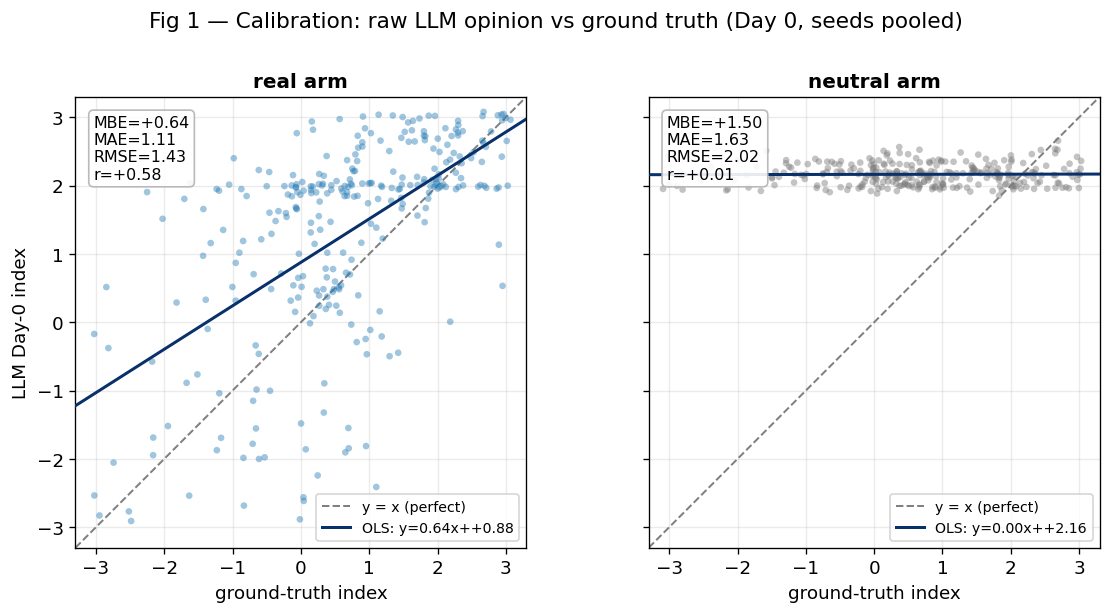

In [7]:
lims = (-3.3, 3.3)
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.9), sharex=True, sharey=True)
rng = np.random.default_rng(0)
for ax, arm in zip(axes, ["real", "neutral"]):
    d = pkg[pkg.arm == arm]
    m = calib_metrics(d.gtv, d.llm)
    ax.plot(lims, lims, ls="--", c="0.5", lw=1.2, zorder=1, label="y = x (perfect)")
    jx = rng.normal(0, 0.05, len(d)); jy = rng.normal(0, 0.05, len(d))
    ax.scatter(d.gtv + jx, d.llm + jy, s=16, alpha=0.45, color=ARM_COLOR[arm], edgecolors="none", zorder=2)
    if np.isfinite(m["OLS_slope"]):
        xs = np.array(lims)
        ax.plot(xs, m["OLS_slope"] * xs + m["OLS_intercept"], color="#08306b", lw=1.8, zorder=3,
                label=f"OLS: y={m['OLS_slope']:.2f}x+{m['OLS_intercept']:+.2f}")
    ax.set_title(f"{arm} arm")
    ax.set_xlabel("ground-truth index")
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
    ax.text(0.04, 0.96,
            f"MBE={m['MBE']:+.2f}\nMAE={m['MAE']:.2f}\nRMSE={m['RMSE']:.2f}\nr={m['Pearson_r']:+.2f}",
            transform=ax.transAxes, va="top", ha="left", fontsize=9.5,
            bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.9))
    ax.legend(loc="lower right", fontsize=8.5)
axes[0].set_ylabel("LLM Day-0 index")
fig.suptitle("Fig 1 — Calibration: raw LLM opinion vs ground truth (Day 0, seeds pooled)", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig1_calibration_scatter.png"), bbox_inches="tight")
plt.show()

## 4. Figure 2 — Is the bias a flat offset or GT-dependent?

The anchoring argument is cleanest if the error is a roughly **constant additive offset** (a
thermometer reading a fixed amount too high). Here we plot the per-agent bias `LLM − GT` against
GT for the `real` arm. A flat cloud around the mean-bias line ⇒ clean offset. A downward slope ⇒
low-GT (sceptical) agents are inflated *more* — regression toward the pro-climate mean / the
ceiling squashing high-GT agents.


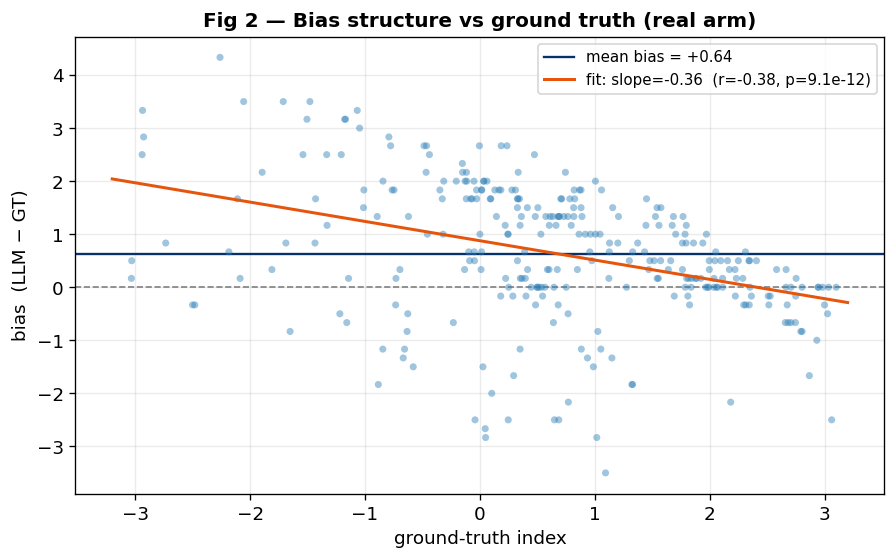

corr(GT, bias) = -0.380 (p=9.11e-12); bias-vs-GT slope = -0.364
Negative slope => sceptics inflated more than greens (regression toward the pro-climate mean),
but the offset stays same-signed across the GT range => anchoring still removes it cleanly.


In [8]:
d = pkg[pkg.arm == "real"].copy()
d["bias"] = d.llm - d.gtv
r_gb, p_gb = pearsonr(d.gtv, d.bias)
lr = linregress(d.gtv, d.bias)

fig, ax = plt.subplots(figsize=(7.6, 4.8))
jx = rng.normal(0, 0.05, len(d))
ax.scatter(d.gtv + jx, d.bias, s=18, alpha=0.45, color=ARM_COLOR["real"], edgecolors="none", zorder=2)
ax.axhline(0, color="0.5", ls="--", lw=1, zorder=1)
ax.axhline(d.bias.mean(), color="#08306b", lw=1.4, zorder=1, label=f"mean bias = {d.bias.mean():+.2f}")
xs = np.array([-3.2, 3.2])
ax.plot(xs, lr.slope * xs + lr.intercept, color="#e6550d", lw=1.8, zorder=3,
        label=f"fit: slope={lr.slope:+.2f}  (r={r_gb:+.2f}, p={p_gb:.1e})")
ax.set_xlabel("ground-truth index"); ax.set_ylabel("bias  (LLM − GT)")
ax.set_title("Fig 2 — Bias structure vs ground truth (real arm)")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig2_bias_vs_gt.png"), bbox_inches="tight")
plt.show()
print(f"corr(GT, bias) = {r_gb:+.3f} (p={p_gb:.2e}); bias-vs-GT slope = {lr.slope:+.3f}")
print("Negative slope => sceptics inflated more than greens (regression toward the pro-climate mean),")
print("but the offset stays same-signed across the GT range => anchoring still removes it cleanly.")

## 5. Figure 3 — Bias decomposition: persona grounding vs the floor

MBE by arm. The persona-free `neutral` floor is the model's unconditional pro-climate prior; the
`real` arm shows how much a real persona pulls each agent back toward its true position. The
`shuffled` arm (a *different* real persona) lands with the real arm — confirming it is *having a
persona* that grounds the level, not the specific identity.


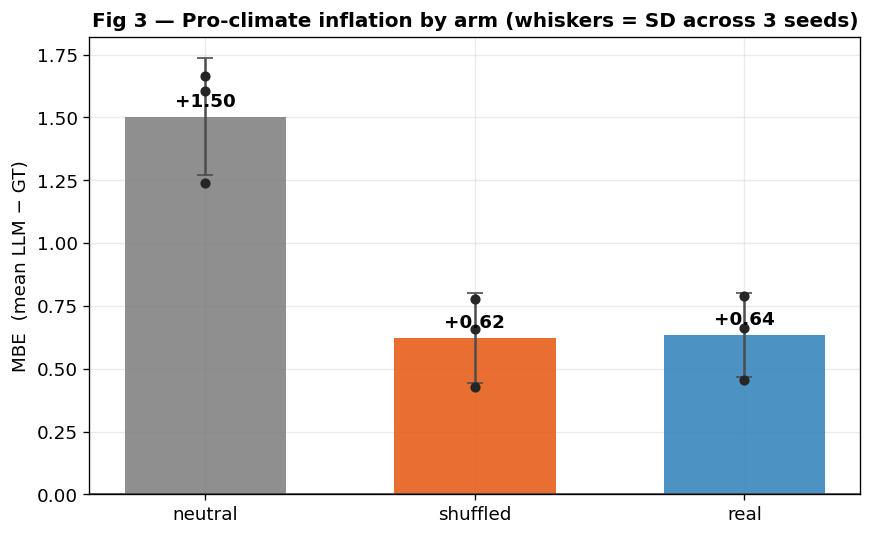

In [9]:
arms3 = ["neutral", "shuffled", "real"]
mbe_by_seed = {a: [ (pkg[(pkg.arm==a)&(pkg.seed==s)].llm - pkg[(pkg.arm==a)&(pkg.seed==s)].gtv).mean()
                    for s in SEEDS ] for a in arms3}
mbe_mean = {a: np.mean(v) for a, v in mbe_by_seed.items()}

fig, ax = plt.subplots(figsize=(7.4, 4.6))
for i, a in enumerate(arms3):
    ax.bar(i, mbe_mean[a], width=0.6, color=ARM_COLOR[a], alpha=0.85, zorder=2,
           yerr=np.std(mbe_by_seed[a], ddof=1), capsize=5, ecolor="0.3")
    ax.scatter([i]*len(SEEDS), mbe_by_seed[a], color="0.15", s=26, zorder=3)
    ax.text(i, mbe_mean[a] + 0.04, f"{mbe_mean[a]:+.2f}", ha="center", fontweight="bold")
ax.axhline(0, color="0.3", lw=1)
ax.set_xticks(range(3)); ax.set_xticklabels(arms3)
ax.set_ylabel("MBE  (mean LLM − GT)")
ax.set_title("Fig 3 — Pro-climate inflation by arm (whiskers = SD across 3 seeds)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig3_bias_decomposition.png"), bbox_inches="tight")
plt.show()

## 6. Per-policy calibration

The same standard metrics computed separately for each of the six policies (`real` arm, seeds
pooled, per-policy scale −3…+3). This shows whether the inflation is uniform or concentrated in
particular (e.g. cost-framed) policies.


In [10]:
rows = []
for pid in sorted(pol.policy_id.unique()):
    d = pol[(pol.arm == "real") & (pol.policy_id == pid)]
    m = calib_metrics(d.gtv, d.llm)
    rows.append({"policy": POLICY_LABEL.get(pid, pid),
                 "MBE": m["MBE"], "MAE": m["MAE"], "RMSE": m["RMSE"],
                 "Pearson_r": m["Pearson_r"], "OLS_slope": m["OLS_slope"],
                 "Spearman_rho": m["Spearman_rho"]})
per_policy = pd.DataFrame(rows).set_index("policy").sort_values("MBE")
per_policy.round(3)

,MBE,MAE,RMSE,Pearson_r,OLS_slope,Spearman_rho
policy,,,,,,
Green housing,-0.153,1.307,1.794,0.336,0.311,0.304
Renewable energy,0.333,1.000,1.512,0.294,0.202,0.377
Ban fossil licences,0.360,1.520,2.033,0.521,0.605,0.544
Climate compensation,0.677,1.837,2.336,0.419,0.532,0.439
Carbon tax,0.960,1.720,2.217,0.377,0.384,0.389
Ban petrol cars,1.637,2.043,2.566,0.386,0.243,0.464


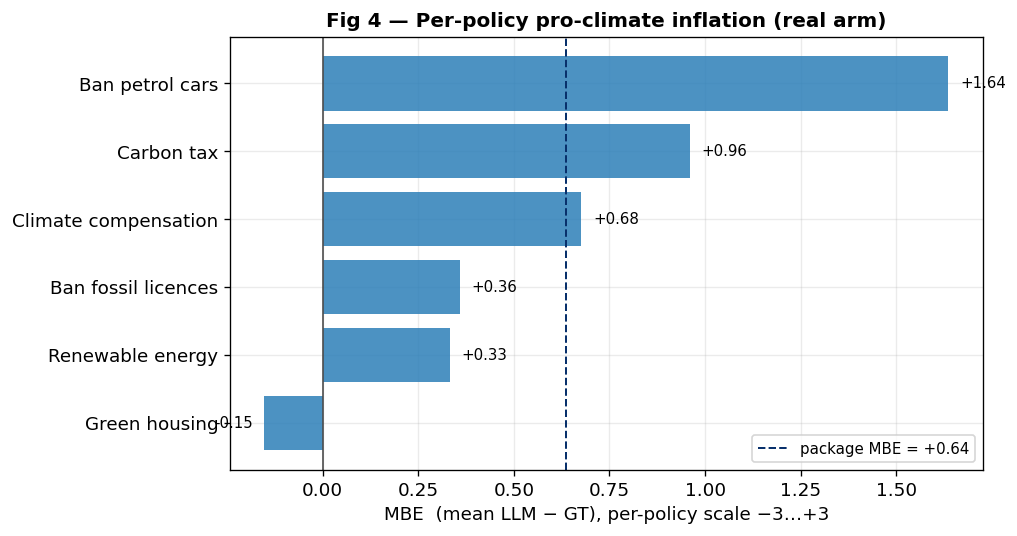

In [11]:
fig, ax = plt.subplots(figsize=(8.6, 4.6))
order = per_policy.index
ax.barh(range(len(order)), per_policy["MBE"], color=ARM_COLOR["real"], alpha=0.85, zorder=2)
ax.axvline(0, color="0.3", lw=1)
ax.axvline(mbe_real, color="#08306b", ls="--", lw=1.2, label=f"package MBE = {mbe_real:+.2f}")
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
ax.set_xlabel("MBE  (mean LLM − GT), per-policy scale −3…+3")
ax.set_title("Fig 4 — Per-policy pro-climate inflation (real arm)")
for i, v in enumerate(per_policy["MBE"]):
    ax.text(v + (0.03 if v >= 0 else -0.03), i, f"{v:+.2f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9)
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig4_per_policy_mbe.png"), bbox_inches="tight")
plt.show()

## 7. Ceiling / regression-to-mean check

The opinion scale stops at +3. Agents already near the top can't move further, which mechanically
compresses the OLS slope below 1 and steepens the bias-vs-GT slope. We quantify how much of the
sample sits at the ceiling so the compression in Figs 1–2 is read correctly (a scale artefact, not
a modelling failure) — this is the hook Tier 2 (scale-robustness) will pick up.


In [12]:
pol_real = pol[pol.arm == "real"]
gt_ceil  = (pkg[pkg.arm == "real"].gtv >= 3.0 - 1e-9).mean()
pol_gt_ceil = (pol_real.gtv >= 3).mean()
pol_gt_floor = (pol_real.gtv <= -3).mean()
print(f"Package GT at +3 ceiling:         {gt_ceil*100:.1f}% of agents")
print(f"Per-policy GT at +3 ceiling:      {pol_gt_ceil*100:.1f}% of responses")
print(f"Per-policy GT at -3 floor:        {pol_gt_floor*100:.1f}% of responses")
print(f"Package OLS slope (real):         {battery.loc['real','OLS_slope']:.3f}  (compression signature)")
print(f"corr(GT, bias) (real):            {r_gb:+.3f}")
print()
print("Interpretation: a non-trivial share of agents start pinned at the pro-climate ceiling, so the")
print("model cannot inflate them further -> the OLS slope < 1 and the negative bias-vs-GT slope are")
print("partly a ceiling artefact. Tier 2 re-checks the downstream findings on ceiling-free rulers.")

Package GT at +3 ceiling:         3.0% of agents
Per-policy GT at +3 ceiling:      23.8% of responses
Per-policy GT at -3 floor:        9.7% of responses
Package OLS slope (real):         0.636  (compression signature)
corr(GT, bias) (real):            -0.380

Interpretation: a non-trivial share of agents start pinned at the pro-climate ceiling, so the
model cannot inflate them further -> the OLS slope < 1 and the negative bias-vs-GT slope are
partly a ceiling artefact. Tier 2 re-checks the downstream findings on ceiling-free rulers.


## 8. The anchor mechanism, and why it removes this bias — Figure 5

From `src/cag/abm/sim.py::_run_day0`:

```python
if anchor_mode == "llm_survey":
    _run_baseline_surveys(...)          # LLM derives the number  → what we measured above (biased)
else:
    for agent, policy in ...:
        if anchor_mode == "ground_truth":
            agent.seed_opinion_from_ground_truth(policy, day=0)      # Day-0 := real YouGov, no LLM
        else:  # ground_truth_with_rationale  (production default)
            agent.seed_opinion_with_rationale(policy, day=0, ...)    # Day-0 := GT; LLM writes only the rationale
```

Under the production anchor the Day-0 **number** is the ground truth, so Day-0 calibration is
**MBE = 0, MAE = 0, ρ = 1.0 by construction** — the LLM contributes only a *rationale* consistent
with that number, which grounds the subsequent dynamics. (Confirmed empirically on a prior
production run: *"Day-0 index = the GT mean, ρ = 1.0, MAE = 0 by construction"* — see
`result_report.md`.) Fig 5 contrasts the two worlds.


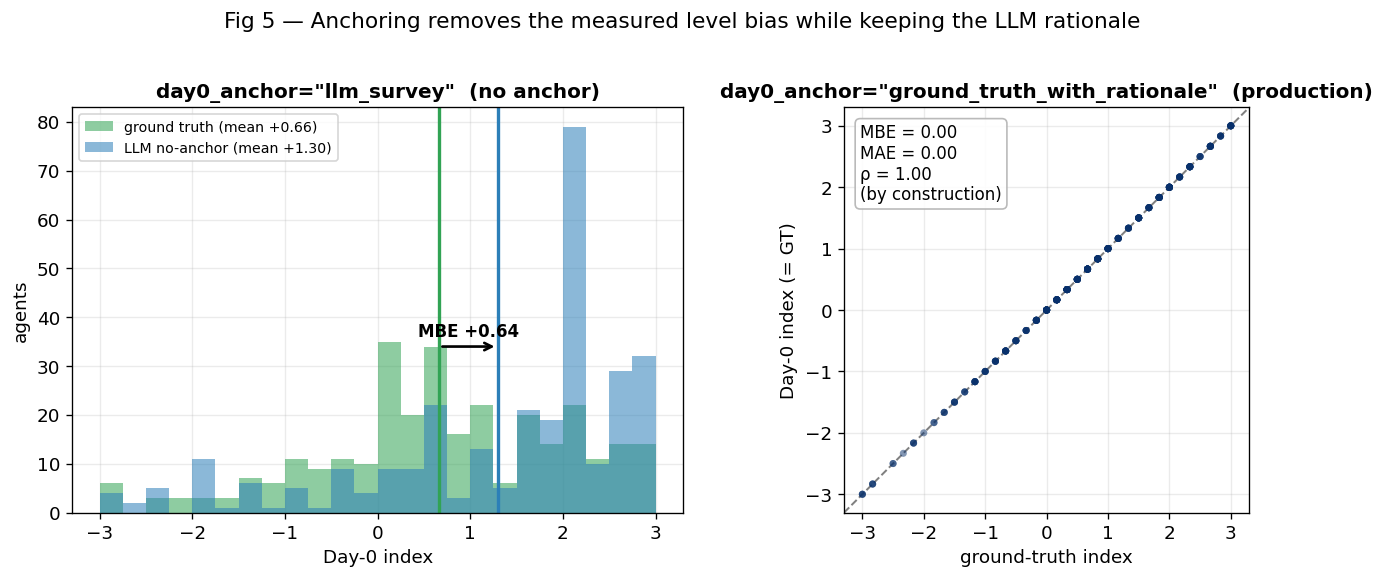

In [13]:
d = pkg[pkg.arm == "real"]
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 4.7))

# Left: no-anchor world — LLM Day-0 distribution vs GT distribution (misaligned means)
bins = np.linspace(-3, 3, 25)
axL.hist(d.gtv,  bins=bins, alpha=0.55, color=GT_COLOR,           label=f"ground truth (mean {d.gtv.mean():+.2f})")
axL.hist(d.llm, bins=bins, alpha=0.55, color=ARM_COLOR["real"], label=f"LLM no-anchor (mean {d.llm.mean():+.2f})")
axL.axvline(d.gtv.mean(),  color=GT_COLOR,          lw=2)
axL.axvline(d.llm.mean(), color=ARM_COLOR["real"], lw=2)
axL.annotate("", xy=(d.llm.mean(), 34), xytext=(d.gtv.mean(), 34),
             arrowprops=dict(arrowstyle="->", color="black", lw=1.6))
axL.text((d.gtv.mean()+d.llm.mean())/2, 36, f"MBE {mbe_real:+.2f}", ha="center", fontsize=10, fontweight="bold")
axL.set_title('day0_anchor="llm_survey"  (no anchor)')
axL.set_xlabel("Day-0 index"); axL.set_ylabel("agents"); axL.legend(fontsize=8.5, loc="upper left")

# Right: anchored world — Day-0 := GT by construction (points on y=x)
axR.plot([-3.3, 3.3], [-3.3, 3.3], ls="--", c="0.5", lw=1.2, zorder=1)
axR.scatter(d.gtv, d.gtv, s=18, alpha=0.5, color="#08306b", edgecolors="none", zorder=2)
axR.set_xlim(-3.3, 3.3); axR.set_ylim(-3.3, 3.3); axR.set_aspect("equal")
axR.set_title('day0_anchor="ground_truth_with_rationale"  (production)')
axR.set_xlabel("ground-truth index"); axR.set_ylabel("Day-0 index (= GT)")
axR.text(0.04, 0.96, "MBE = 0.00\nMAE = 0.00\nρ = 1.00\n(by construction)",
         transform=axR.transAxes, va="top", ha="left", fontsize=10,
         bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.9))
fig.suptitle("Fig 5 — Anchoring removes the measured level bias while keeping the LLM rationale", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig5_anchor_demonstration.png"), bbox_inches="tight")
plt.show()

### Takeaway

* The raw no-anchor model inflates the package pro-climate index by **MBE ≈ +0.6** above ground
  truth; the persona-free floor is far higher (**≈ +1.5**). Having *a* persona pulls the level
  much of the way back, but a residual pro-climate tilt remains.
* The error is a **level** problem, not a **rank** problem: Spearman ρ ≈ 0.62 is preserved, and the
  bias is a same-signed offset across the GT range (steepened somewhat by the +3 ceiling — a scale
  artefact Tier 2 will re-examine).
* Because the error is a preserved-order offset, the production anchor
  `ground_truth_with_rationale` removes it **by construction** (Day-0 MBE = 0, ρ = 1.0) while
  retaining an LLM-authored rationale for the dynamics.
* **This is the empirical licence for the "difference engine" stance:** absolute levels are not
  trustworthy, but anchored, rank-faithful *differences between conditions* are — which is exactly
  what Tiers 1–3 go on to validate.

*Numbers → `docs/result_report.md`; framing → `docs/research_notes.md` (both as a follow-up step).*
